In [44]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans

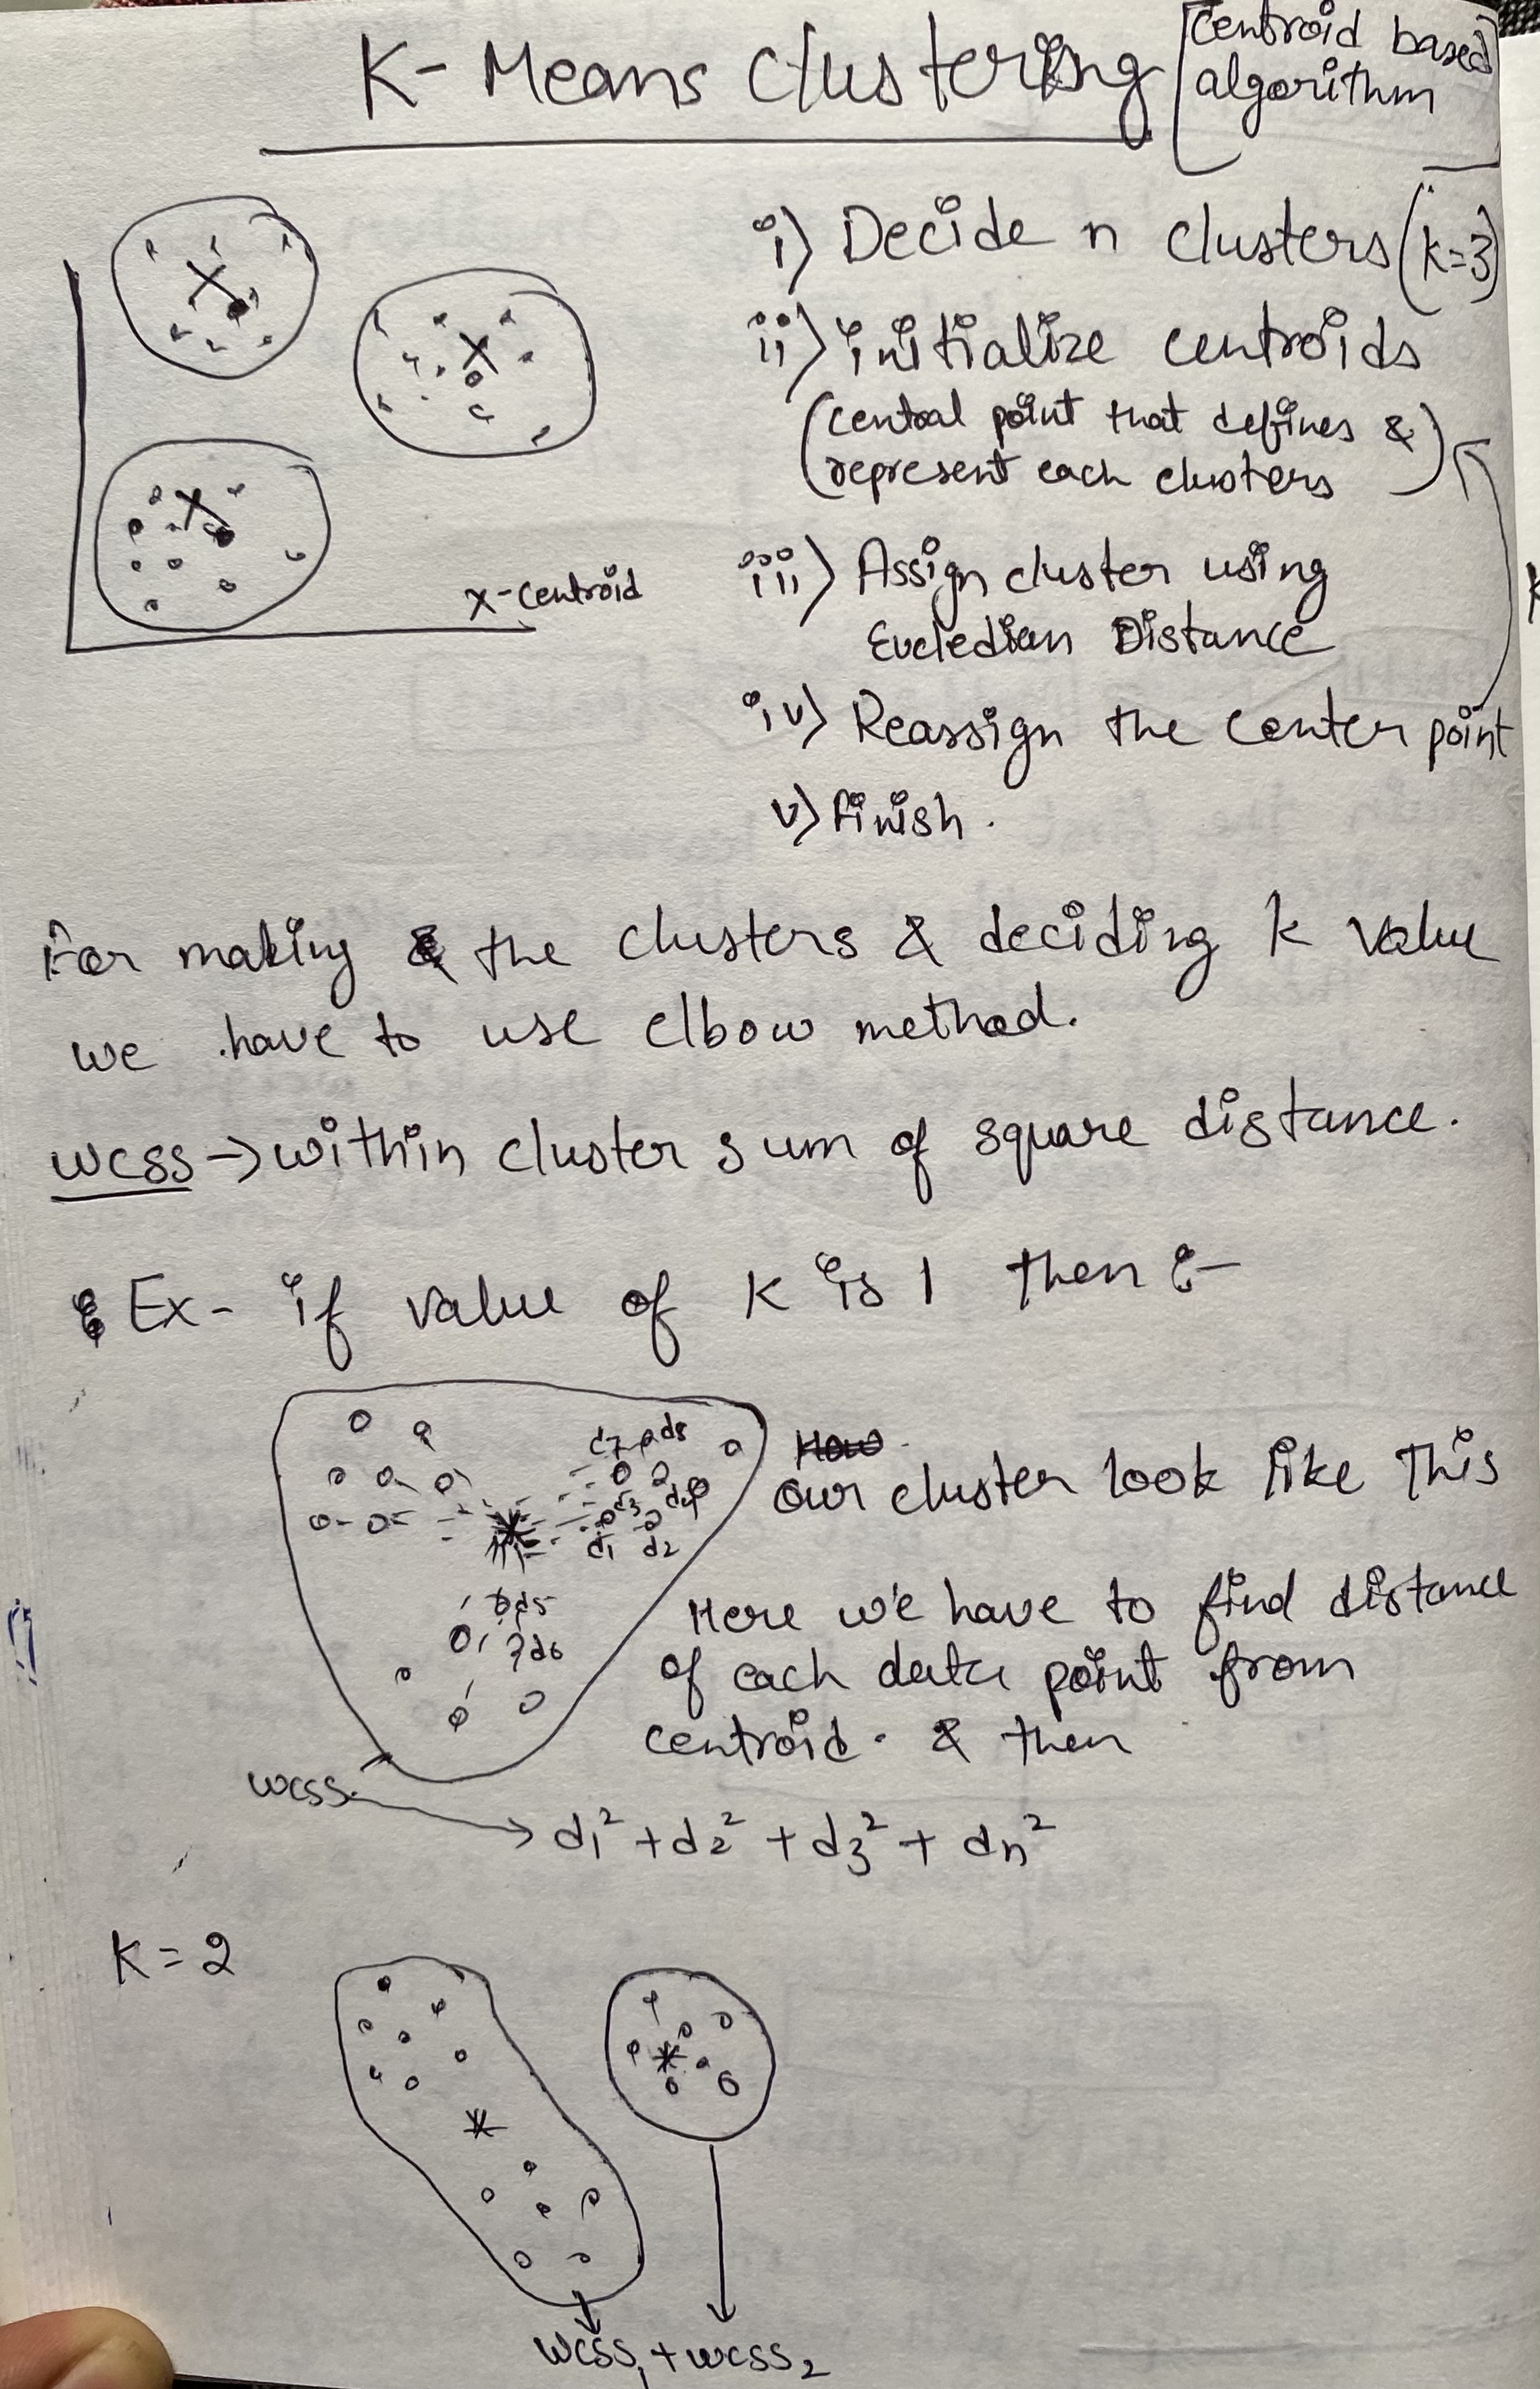
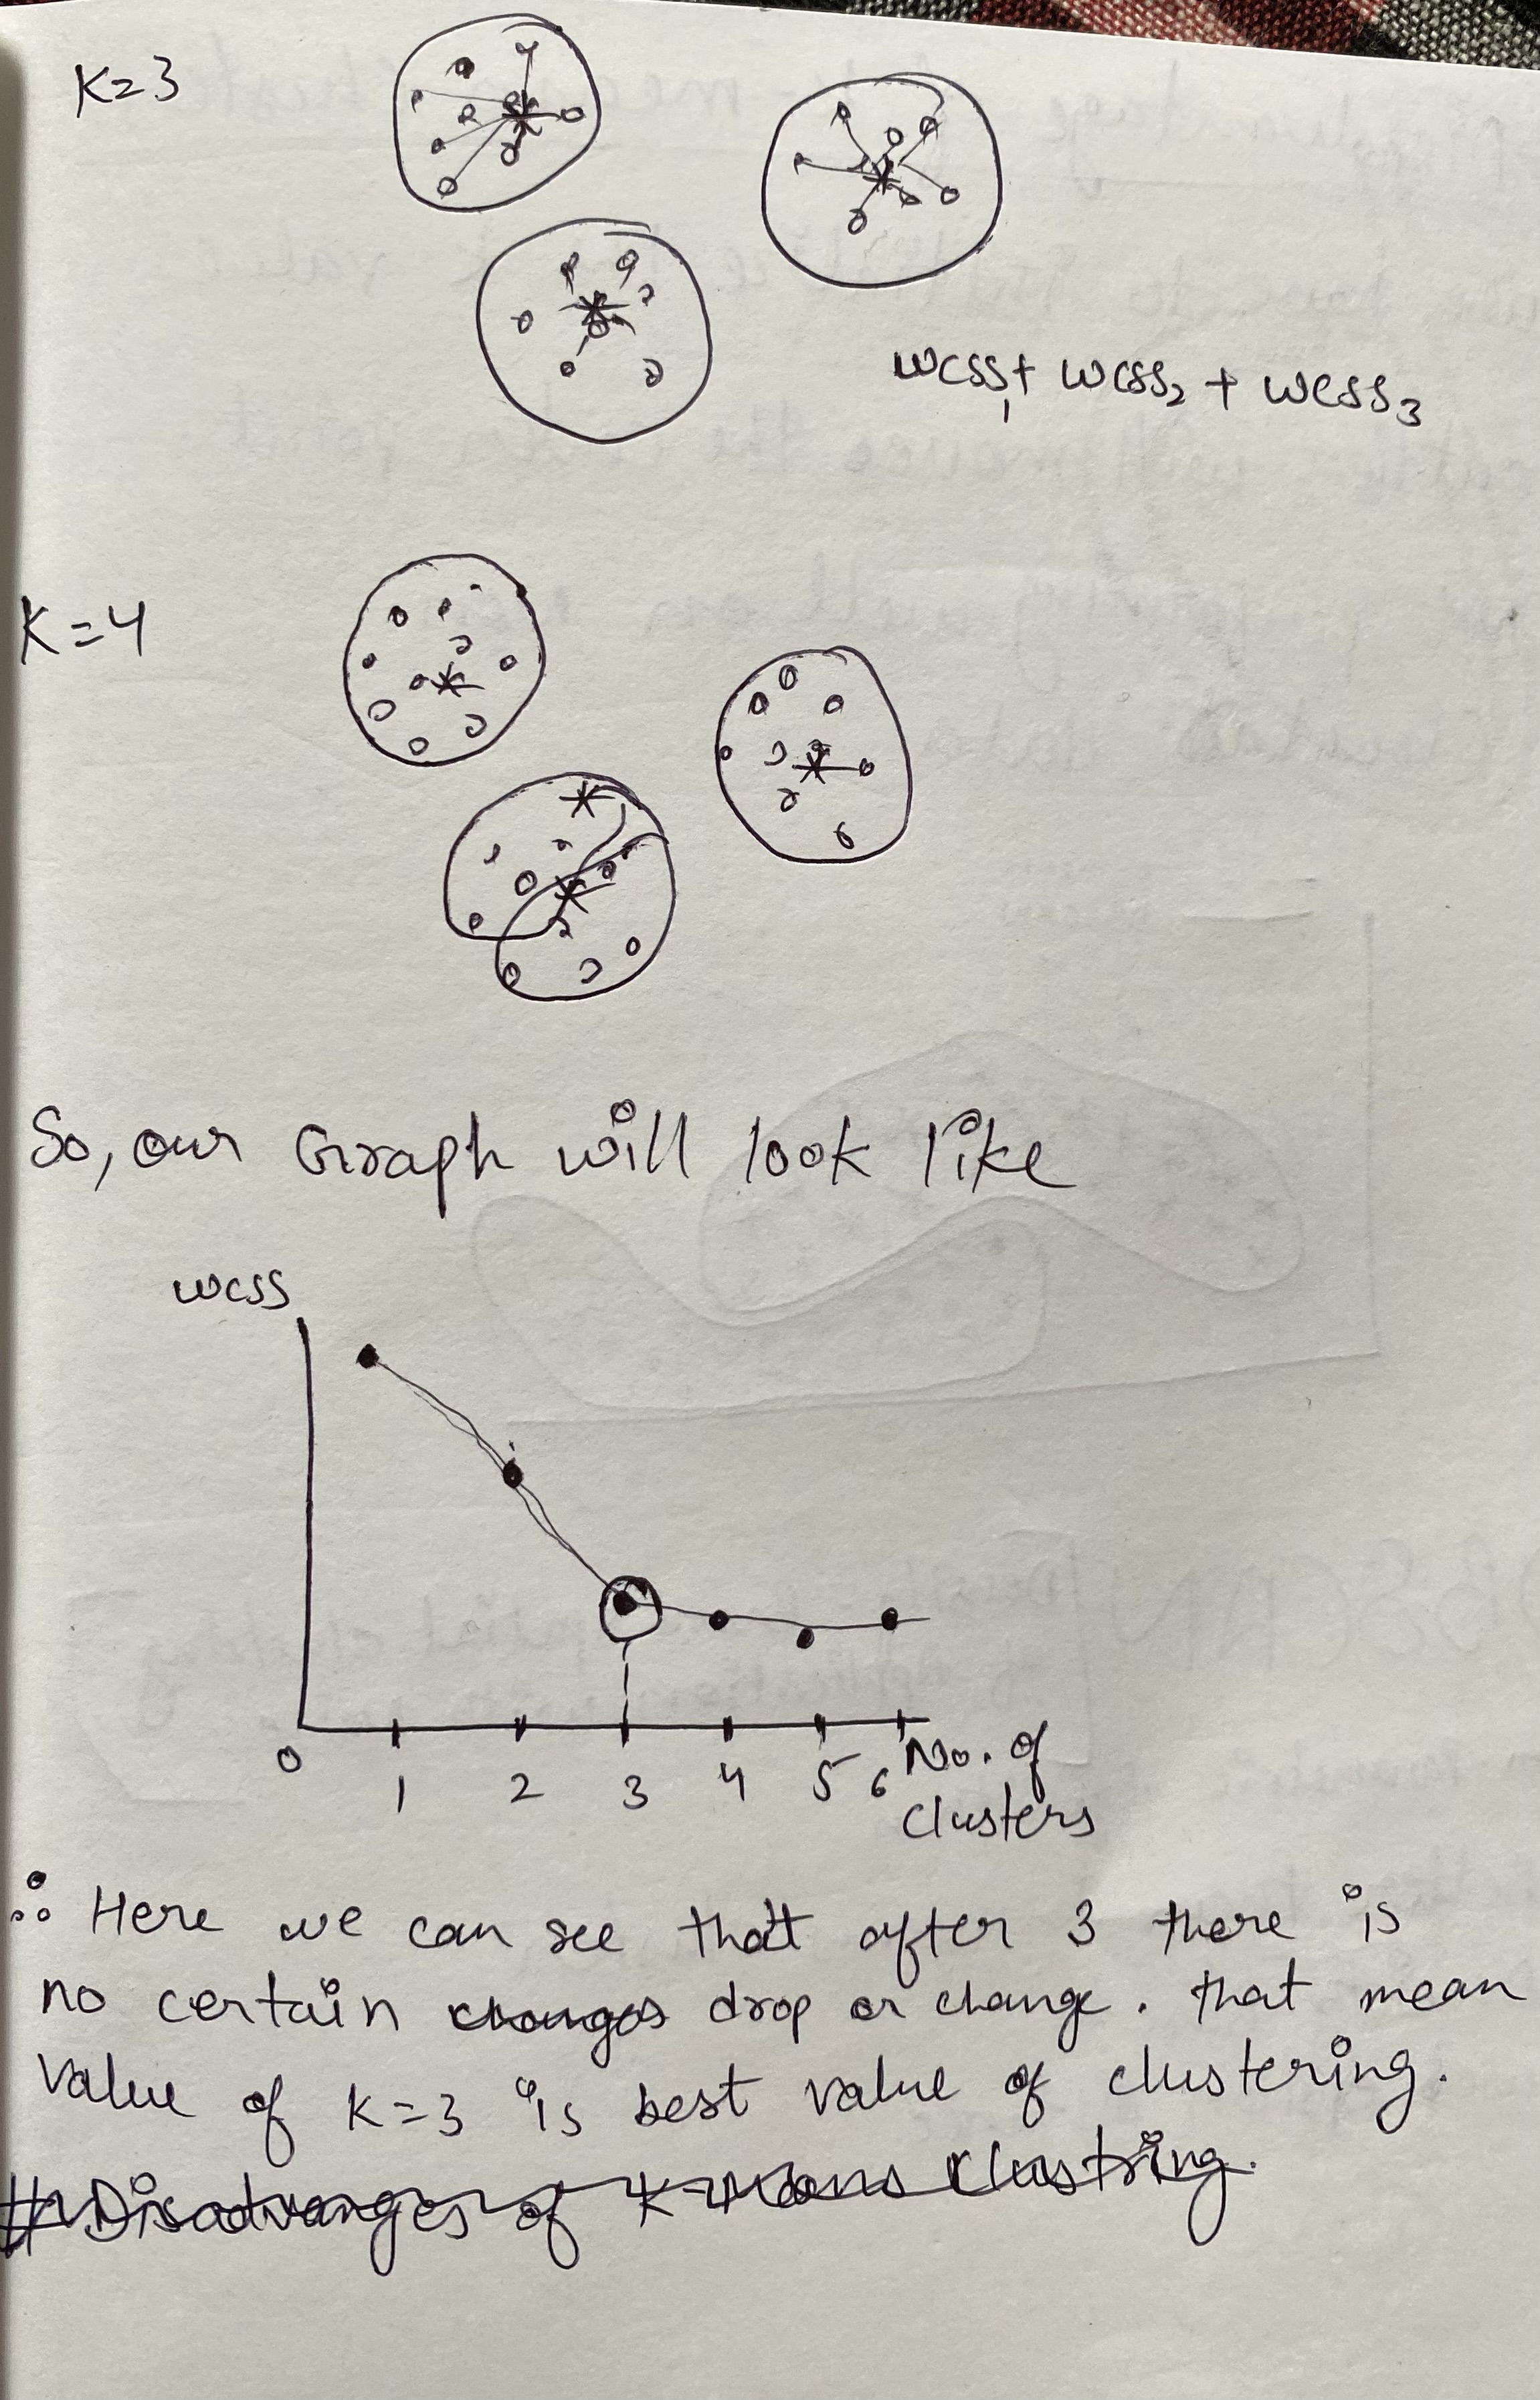
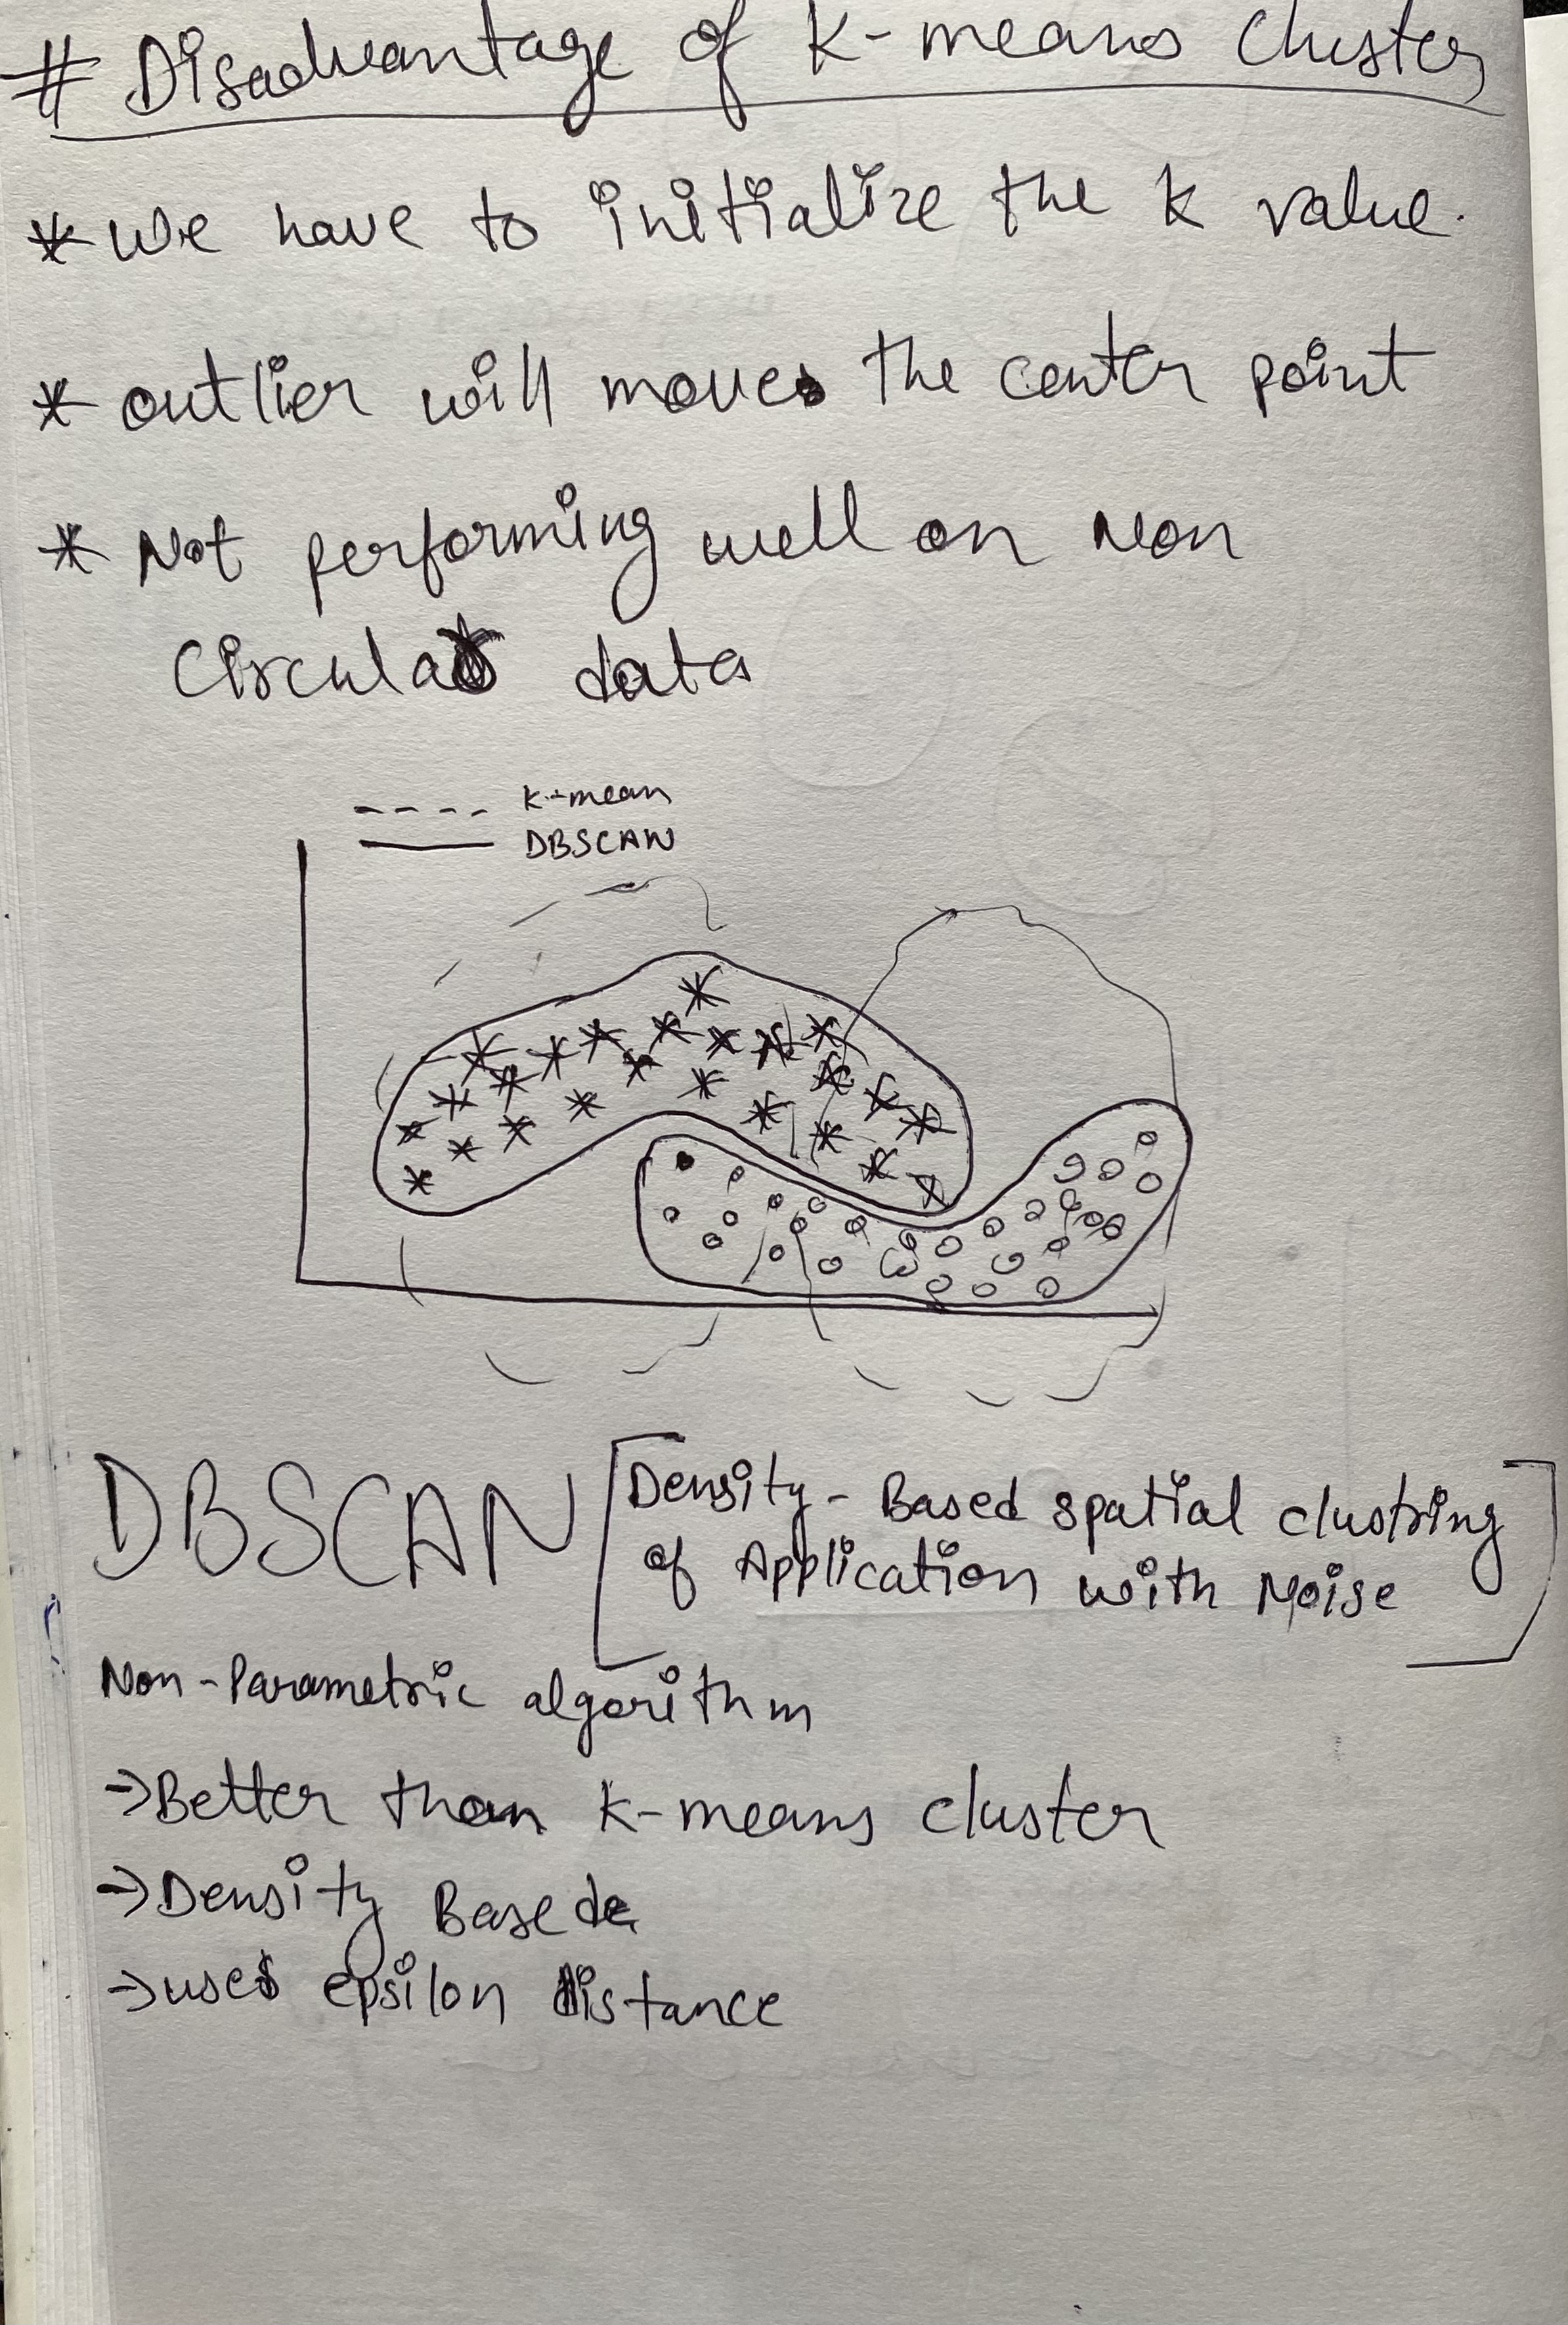

In [20]:
df = pd.read_csv("Mall_Customers.csv")

In [21]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [23]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [24]:
label = LabelEncoder()
df['Gender'] = label.fit_transform(df['Gender'])

In [25]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40
...,...,...,...,...,...
195,196,0,35,120,79
196,197,0,45,126,28
197,198,1,32,126,74
198,199,1,32,137,18


In [36]:
# df.drop('CustomerID', inplace=True, axis=1)

x = df[['Annual Income (k$)','Spending Score (1-100)']]

In [37]:
scale = StandardScaler() 
x_scaled = scale.fit_transform(x)

In [38]:
wcss = []
k_range = range(1,11) 

for k in k_range: 
    km = KMeans(n_clusters=k, random_state=43)
    model = km.fit(x_scaled)
    wcss.append(km.inertia_) #intertia_ is used for wcss

In [39]:
wcss

[400.0,
 269.6910121927639,
 157.7040081503595,
 109.22822707921344,
 65.56840815571681,
 60.14284754184912,
 52.49832217497557,
 44.367781970210984,
 41.13164705306974,
 33.136240172944916]

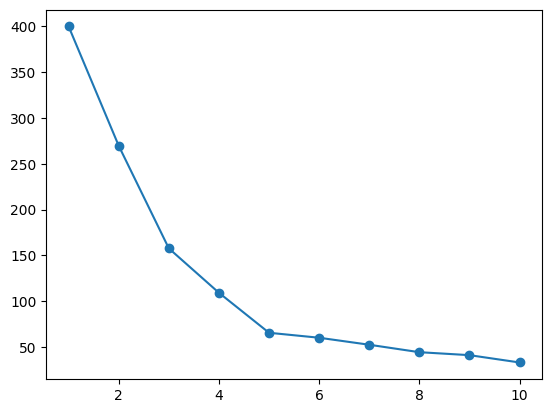

In [46]:
plt.plot(k_range, wcss, marker = "o")
# k = 5

In [55]:
kmeans = KMeans(n_clusters=5, random_state=42)

clus = kmeans.fit_predict(x_scaled)

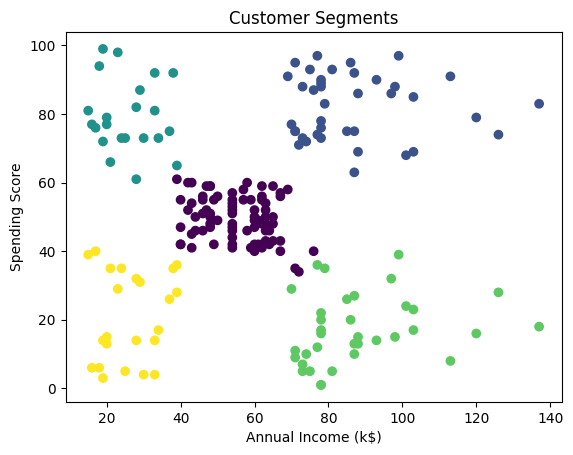

In [57]:
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c = clus
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()